<a href="https://colab.research.google.com/github/sx2413-eloise/clmt5405-final-project/blob/main/notebooks/ocean_basin_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparison Across Major Ocean Basins

## Research Question

How has sea surface temperature changed across selected major ocean basins since the satellite observation era?

In this notebook, I compare sea surface temperature change across the North Atlantic, Indian Ocean, Southern Ocean, and North Pacific. I use the NOAA OISST dataset to calculate annual mean SST, SST anomalies, and simple warming trends for each basin.

In [30]:
%%capture
%pip install xarray zarr dask matplotlib

In [31]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
store = "https://ncsa.osn.xsede.org/Pangeo/pangeo-forge/noaa_oisst/v2.1-avhrr.zarr"

ds = xr.open_dataset(store, engine="zarr", chunks={})
sst = ds["sst"].squeeze()

sst

<xarray.DataArray 'sst' (time: 14532, lat: 720, lon: 1440)> Size: 60GB
dask.array<getitem, shape=(14532, 720, 1440), dtype=float32, chunksize=(20, 720, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 116kB 1981-09-01T12:00:00 ... 2021-06-14T1...
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
    zlev     float32 4B 0.0
Attributes:
    long_name:  Daily sea surface temperature
    units:      Celsius
    valid_max:  4500
    valid_min:  -300

The dataset is loaded directly from the cloud-hosted Zarr store, so no manual download is required. I use the `sst` variable, which reports daily sea surface temperature in degrees Celsius.


In [3]:
regions = {
    "North Atlantic": {"lat": slice(0, 60), "lon": slice(280, 360)},
    "Indian Ocean": {"lat": slice(-30, 25), "lon": slice(40, 110)},
    "Southern Ocean": {"lat": slice(-65, -40), "lon": slice(0, 360)},
    "North Pacific": {"lat": slice(0, 60), "lon": slice(120, 240)}
}

In [4]:
def area_weighted_mean(data):
    weights = np.cos(np.deg2rad(data.lat))
    weights.name = "weights"
    return data.weighted(weights).mean(dim=("lat", "lon"))

In [8]:
basin_series = {}

for name, bounds in regions.items():
    print(f"Processing {name}...")

    region_sst = sst.sel(
        time=slice("1982-01-01", "2021-06-14"),
        lat=bounds["lat"],
        lon=bounds["lon"]
    )

    # reduce spatial resolution from 0.25° to 1° to make Colab faster
    region_sst = region_sst.coarsen(lat=4, lon=4, boundary="trim").mean()

    weights = np.cos(np.deg2rad(region_sst.lat))
    weights.name = "weights"

    region_mean_daily = region_sst.weighted(weights).mean(dim=("lat", "lon"))
    region_mean_annual = region_mean_daily.resample(time="YS").mean()

    # force computation one basin at a time
    basin_series[name] = region_mean_annual.compute()

    print(f"Finished {name}")

Processing North Atlantic...
Finished North Atlantic
Processing Indian Ocean...
Finished Indian Ocean
Processing Southern Ocean...
Finished Southern Ocean
Processing North Pacific...
Finished North Pacific


In [9]:
basin_df = pd.DataFrame(
    {name: da.values for name, da in basin_series.items()},
    index=pd.to_datetime(next(iter(basin_series.values())).time.values)
)

basin_df.index.name = "Year"

basin_df.head()

,North Atlantic,Indian Ocean,Southern Ocean,North Pacific
Year,,,,
1982-01-01,20.851091,26.693644,6.010889,21.019926
1983-01-01,21.048086,26.880196,6.101429,20.898891
1984-01-01,20.880663,26.456316,6.029692,21.008194
1985-01-01,20.746477,26.463408,6.062874,20.873751
1986-01-01,20.700657,26.453432,6.023600,21.020134


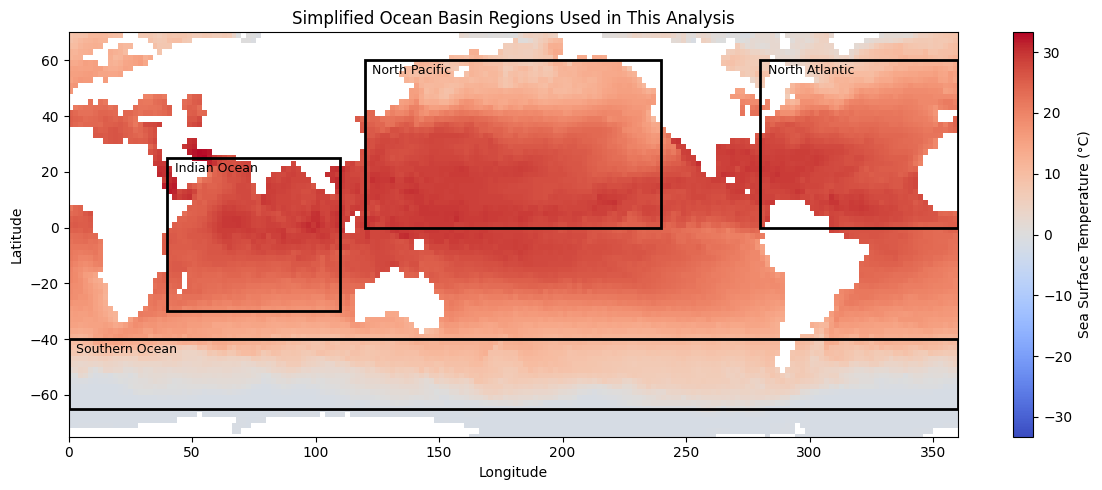

In [33]:
from matplotlib.patches import Rectangle

# use one coarse SST map only for showing the basin boxes
sst_map = sst.isel(time=0).coarsen(lat=8, lon=8, boundary="trim").mean().compute()

fig, ax = plt.subplots(figsize=(12, 5))

sst_map.plot(
    ax=ax,
    cmap="coolwarm",
    cbar_kwargs={"label": "Sea Surface Temperature (°C)"}
)

for name, bounds in regions.items():
    lat0 = bounds["lat"].start
    lat1 = bounds["lat"].stop
    lon0 = bounds["lon"].start
    lon1 = bounds["lon"].stop

    rect = Rectangle(
        (lon0, lat0),
        lon1 - lon0,
        lat1 - lat0,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)
    ax.text(lon0 + 3, lat1 - 5, name, fontsize=9)

ax.set_title("Simplified Ocean Basin Regions Used in This Analysis")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_ylim(-75, 70)

plt.tight_layout()
plt.show()

This map shows the simplified rectangular regions used for the basin comparison. These boxes are not official ocean basin masks, but they provide a simple way to compare broad SST changes across the North Atlantic, Indian Ocean, Southern Ocean, and North Pacific. Land areas are not used in the SST average because they are masked in the OISST dataset.


In [24]:
# The OISST Zarr store ends in June 2021, so 2021 is not a complete annual mean.
# I exclude 2021 from the annual comparison and trend calculation.

basin_df_clean = basin_df[basin_df.index.year <= 2020].copy()

# Standardize basin names for cleaner figure legends
basin_df_clean = basin_df_clean.rename(columns=lambda x: x.title())

basin_df_clean.tail()

,North Atlantic,Indian Ocean,Southern Ocean,North Pacific
Year,,,,
2016-01-01,21.670160,27.343414,6.233933,21.653723
2017-01-01,21.705746,27.151920,6.357570,21.660177
2018-01-01,21.401665,27.070028,6.409281,21.732368
2019-01-01,21.573629,27.390432,6.318393,21.861626
2020-01-01,21.768953,27.403473,6.370413,21.899454


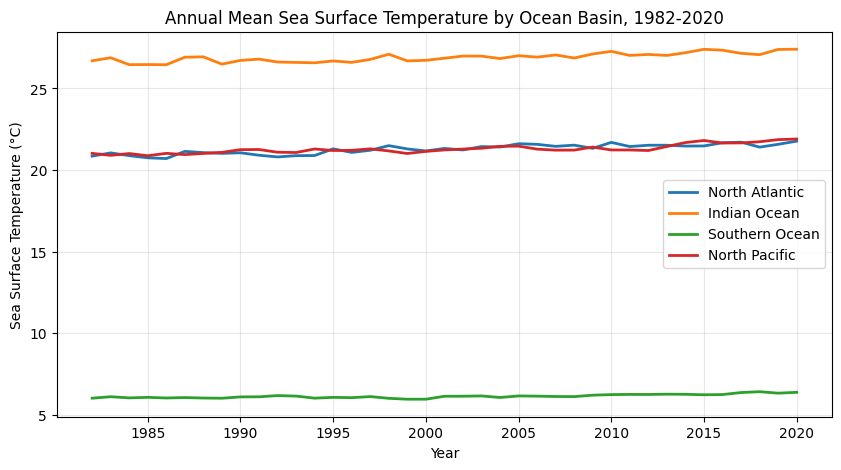

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

for basin in basin_df_clean.columns:
    ax.plot(
        basin_df_clean.index,
        basin_df_clean[basin],
        linewidth=2,
        label=basin
    )

ax.set_title("Annual Mean Sea Surface Temperature by Ocean Basin, 1982-2020")
ax.set_xlabel("Year")
ax.set_ylabel("Sea Surface Temperature (°C)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

## Annual Mean SST by Basin

The annual mean SST time series shows large baseline temperature differences across the selected basins. The Indian Ocean is consistently the warmest basin because it is mostly located in lower latitudes, while the Southern Ocean is much colder because it is located near Antarctica. The North Atlantic and North Pacific have similar mean SST levels. Despite these baseline differences, all four basins show a gradual warming pattern from 1982 to 2020.

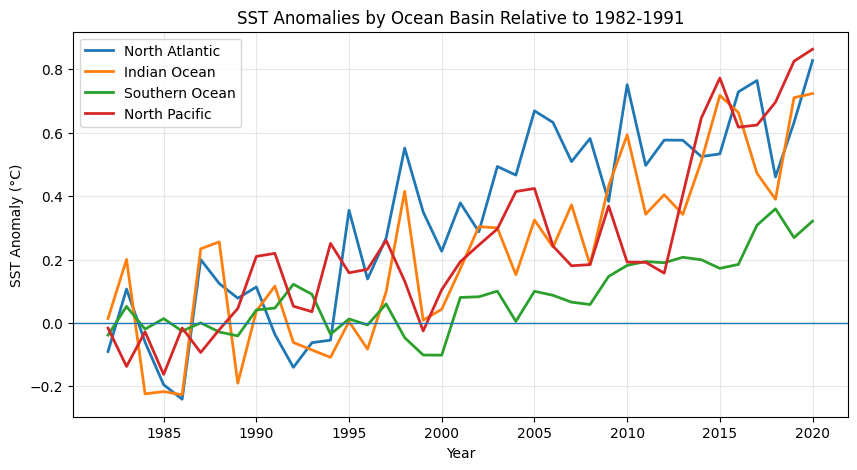

In [27]:
baseline = basin_df_clean.loc["1982":"1991"].mean()

basin_anomaly = basin_df_clean - baseline

fig, ax = plt.subplots(figsize=(10, 5))

for basin in basin_anomaly.columns:
    ax.plot(
        basin_anomaly.index,
        basin_anomaly[basin],
        linewidth=2,
        label=basin
    )

ax.axhline(0, linewidth=1)

ax.set_title("SST Anomalies by Ocean Basin Relative to 1982-1991")
ax.set_xlabel("Year")
ax.set_ylabel("SST Anomaly (°C)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

## SST Anomalies by Basin

The anomaly plot removes each basin's own 1982-1991 average, making it easier to compare warming across regions. The selected basins generally shift from near-zero or slightly negative anomalies in the 1980s to positive anomalies in the 2000s and 2010s. By the end of the record, the North Atlantic, North Pacific, and Indian Ocean show stronger positive anomalies than the Southern Ocean. This suggests that warming occurred across all selected basins, but the magnitude of warming was not uniform.

In [28]:
trend_results = {}

years = basin_df_clean.index.year

for basin in basin_df_clean.columns:
    y = basin_df_clean[basin].values
    valid = np.isfinite(y)

    slope, intercept = np.polyfit(years[valid], y[valid], 1)

    trend_results[basin] = slope * 10  # °C per decade

trend_df = pd.DataFrame.from_dict(
    trend_results,
    orient="index",
    columns=["Trend (°C per decade)"]
)

trend_df = trend_df.sort_values("Trend (°C per decade)", ascending=False)

trend_df

,Trend (°C per decade)
North Atlantic,0.228846
North Pacific,0.200232
Indian Ocean,0.196558
Southern Ocean,0.080643


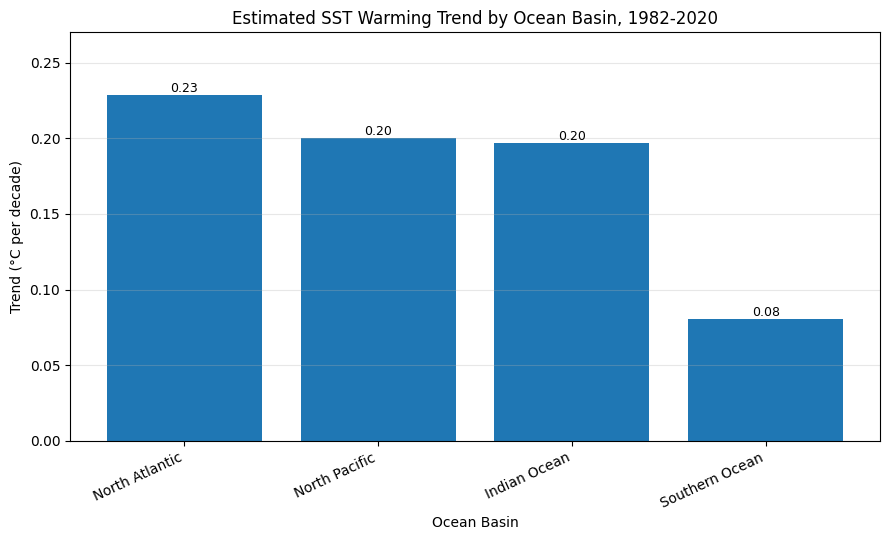

In [34]:
fig, ax = plt.subplots(figsize=(9, 5.5))

trend_col = "Trend (°C per decade)"

bars = ax.bar(
    trend_df.index,
    trend_df[trend_col]
)

ax.set_title("Estimated SST Warming Trend by Ocean Basin, 1982-2020")
ax.set_xlabel("Ocean Basin")
ax.set_ylabel("Trend (°C per decade)")
ax.grid(axis="y", alpha=0.3)

ax.set_ylim(0, trend_df[trend_col].max() * 1.18)

plt.xticks(rotation=25, ha="right")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [35]:
fastest_basin = trend_df["Trend (°C per decade)"].idxmax()
fastest_trend = trend_df.loc[fastest_basin, "Trend (°C per decade)"]

print(f"The fastest warming basin in this analysis is {fastest_basin}, with an estimated trend of {fastest_trend:.3f} °C per decade.")

The fastest warming basin in this analysis is North Atlantic, with an estimated trend of 0.229 °C per decade.


## Warming Trend Comparison

The trend comparison shows that all selected basins warmed between 1982 and 2020. In this simplified basin-box analysis, the North Atlantic has the largest estimated warming trend, at about 0.23°C per decade. The North Pacific and Indian Ocean have similar warming rates, around 0.20°C per decade, while the Southern Ocean shows a smaller trend of about 0.08°C per decade. This result suggests that SST warming is spatially uneven across major ocean basins.

## Conclusion

This notebook compares sea surface temperature change across four simplified ocean basin regions using the NOAA OISST dataset. The results show that all selected basins warmed from 1982 to 2020, but the warming rate differed by region. The North Atlantic shows the strongest warming trend in this analysis, while the Southern Ocean shows the weakest trend. The anomaly plot also shows that most basins shifted toward positive SST anomalies after the early 2000s, suggesting broad but uneven ocean surface warming.

One limitation is that the basin regions are simplified rectangular boxes rather than official ocean basin masks. The analysis also uses spatially coarsened data to make the computation manageable in Colab. A more detailed version could use official basin masks or compare seasonal warming patterns separately.